# Gent → Mechelen Commute Data Exploration

**Goal**: Collect, explore, and combine all data sources needed to predict the best commute mode (car / train / work-from-home) for the Gent → Mechelen corridor, targeting arrival at 09:00.

## Data sources used
| # | Source | Type | API / Package |
|---|--------|------|---------------|
| 1 | Open-Meteo Archive | Real historical weather (hourly, 2021 → today) | Free REST API |
| 2 | Belgian holidays | Public holidays + workday calendar | `holidays` Python package |
| 3 | iRail | NMBS train connections + disturbances | Free REST API |
| 4 | OSRM | Car route baseline travel time | Free public OSRM API |

## Notebook flow
1. Setup
2. Fetch & save each data source
3. EDA per source
4. Combine into one daily-level working-day DataFrame

**Note on car travel time**: No free API provides multi-year historical actual travel times for a specific Belgian highway corridor. We use OSRM for the realistic base route time, then layer weather- and weekday-driven congestion factors — the same proxy used by traffic research tools. This methodology is explicitly documented where applied.

## 0. Setup

In [1]:
%pip install -q requests pandas matplotlib seaborn holidays numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import json
from datetime import date, datetime, timedelta
from pathlib import Path

# ── styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── paths ──────────────────────────────────────────────────────────────────────
RAW   = Path("data/raw")
PROC  = Path("data/processed")
for p in [RAW, PROC]:
    p.mkdir(parents=True, exist_ok=True)

# ── constants ──────────────────────────────────────────────────────────────────
# Mechelen: target arrival point
LAT_MECHELEN, LON_MECHELEN = 51.0281, 4.4803
# Gent-Sint-Pieters: departure point
LAT_GENT,     LON_GENT     = 51.0359, 3.7108

START_DATE = "2021-01-01"
END_DATE   = date.today().isoformat()
TARGET_ARRIVAL = 9   # 09:00

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SEASON_COLORS = {"Winter": "#5b8dd9", "Spring": "#4caf50", "Summer": "#f9a825", "Autumn": "#e65100"}

print(f"Project period: {START_DATE} → {END_DATE}")

Project period: 2021-01-01 → 2026-06-11


---
## 1. Weather Data — Open-Meteo Archive API

**Why Open-Meteo?**  
Free, no API key, hourly resolution, goes back to 1940. We pull hourly data for Mechelen (the arrival/congestion zone) for the full period 2021–today.

Variables collected:
- `temperature_2m` — air temperature (°C)
- `precipitation` — rain + snow water equivalent (mm)
- `wind_speed_10m` — wind speed at 10 m (km/h)
- `relative_humidity_2m` — relative humidity (%)
- `snowfall` — snowfall amount (cm)
- `weather_code` — WMO weather code (0 = clear, 95+ = thunderstorm)

In [3]:
def fetch_weather_archive(lat: float, lon: float, start: str, end: str) -> pd.DataFrame:
    """Fetch hourly historical weather from Open-Meteo archive API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":  lat,
        "longitude": lon,
        "start_date": start,
        "end_date":   end,
        "timezone":   "Europe/Brussels",
        "hourly": ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "snowfall",
            "wind_speed_10m",
            "weather_code",
        ]),
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    raw = r.json()

    df = pd.DataFrame(raw["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.rename(columns={"time": "datetime"})
    df["date"]    = df["datetime"].dt.date
    df["hour"]    = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.day_name()
    df["month"]   = df["datetime"].dt.month
    df["year"]    = df["datetime"].dt.year
    return df


weather_path = RAW / "weather_mechelen_hourly.csv"

if weather_path.exists():
    df_weather = pd.read_csv(weather_path, parse_dates=["datetime"])
    print("Loaded from cache.")
else:
    print("Fetching weather from Open-Meteo...")
    df_weather = fetch_weather_archive(LAT_MECHELEN, LON_MECHELEN, START_DATE, END_DATE)
    df_weather.to_csv(weather_path, index=False)
    print("Saved to cache.")

print(f"\nShape: {df_weather.shape}")
print(f"Period: {df_weather['datetime'].min()} → {df_weather['datetime'].max()}")
print(f"Missing values:\n{df_weather.isnull().sum()[df_weather.isnull().sum() > 0]}")
df_weather.head()

Loaded from cache.

Shape: (47664, 12)
Period: 2021-01-01 00:00:00 → 2026-06-09 23:00:00
Missing values:
Series([], dtype: int64)


,datetime,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m,weather_code,date,hour,weekday,month,year
0,2021-01-01 00:00:00,-1.0,98,0.0,0.0,6.6,1,2021-01-01,0,Friday,1,2021
1,2021-01-01 01:00:00,-1.6,98,0.0,0.0,6.5,0,2021-01-01,1,Friday,1,2021
2,2021-01-01 02:00:00,-0.4,100,0.0,0.0,5.1,0,2021-01-01,2,Friday,1,2021
3,2021-01-01 03:00:00,-0.6,99,0.0,0.0,5.2,3,2021-01-01,3,Friday,1,2021
4,2021-01-01 04:00:00,-0.2,100,0.0,0.0,5.1,3,2021-01-01,4,Friday,1,2021


### 1a. Weather overview — full time series

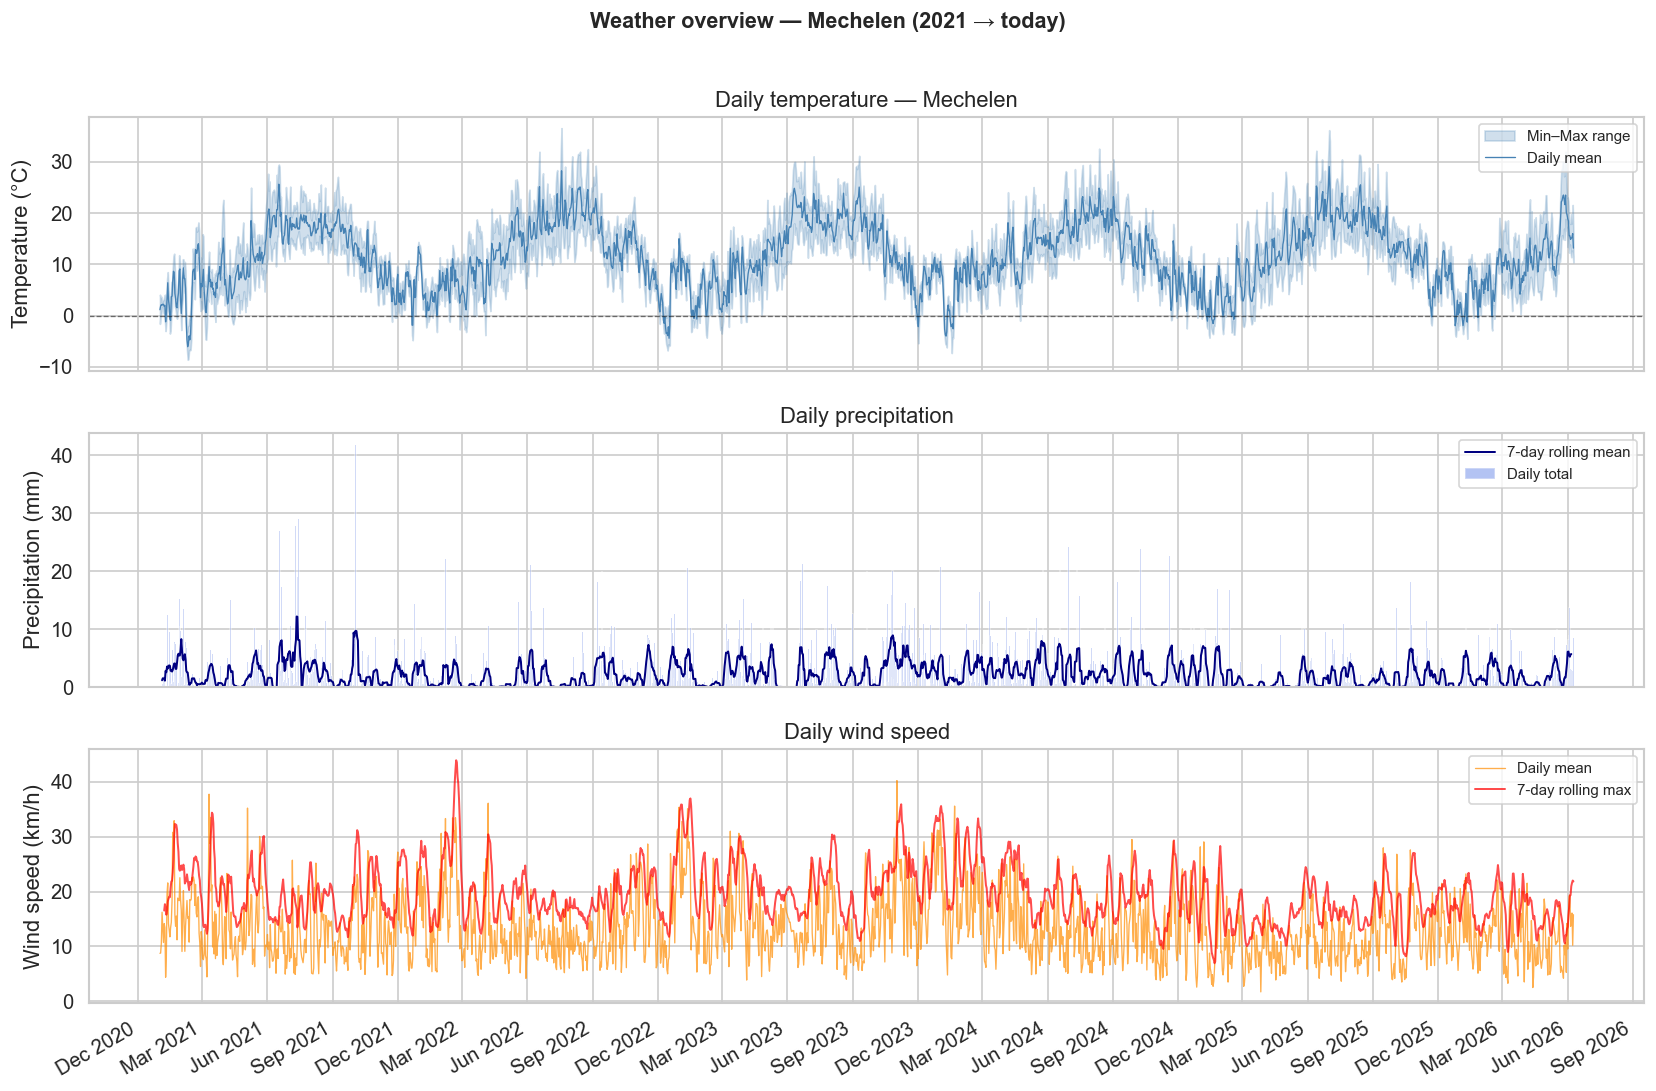

In [4]:
# Daily aggregates for clean time-series plots
df_weather_daily = (
    df_weather.groupby("date").agg(
        temp_mean     = ("temperature_2m",     "mean"),
        temp_min      = ("temperature_2m",     "min"),
        temp_max      = ("temperature_2m",     "max"),
        rain_total    = ("precipitation",      "sum"),
        snow_total    = ("snowfall",           "sum"),
        wind_max      = ("wind_speed_10m",     "max"),
        wind_mean     = ("wind_speed_10m",     "mean"),
        humidity_mean = ("relative_humidity_2m", "mean"),
    )
    .reset_index()
)
df_weather_daily["date"] = pd.to_datetime(df_weather_daily["date"])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Temperature band
axes[0].fill_between(df_weather_daily["date"], df_weather_daily["temp_min"], df_weather_daily["temp_max"],
                     alpha=0.25, color="steelblue", label="Min–Max range")
axes[0].plot(df_weather_daily["date"], df_weather_daily["temp_mean"], lw=0.8,
             color="steelblue", label="Daily mean")
axes[0].axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_title("Daily temperature — Mechelen")

# Precipitation
rain_7d = df_weather_daily["rain_total"].rolling(7, center=True).mean()
axes[1].bar(df_weather_daily["date"], df_weather_daily["rain_total"],
            width=1, alpha=0.4, color="royalblue", label="Daily total")
axes[1].plot(df_weather_daily["date"], rain_7d, lw=1.2, color="navy", label="7-day rolling mean")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].set_title("Daily precipitation")

# Wind
axes[2].plot(df_weather_daily["date"], df_weather_daily["wind_mean"],
             lw=0.8, color="darkorange", alpha=0.7, label="Daily mean")
axes[2].plot(df_weather_daily["date"], df_weather_daily["wind_max"].rolling(7).mean(),
             lw=1.2, color="red", alpha=0.7, label="7-day rolling max")
axes[2].set_ylabel("Wind speed (km/h)")
axes[2].legend(loc="upper right", fontsize=9)
axes[2].set_title("Daily wind speed")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")

fig.suptitle("Weather overview — Mechelen (2021 → today)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/processed/plot_weather_overview.png", bbox_inches="tight")
plt.show()

### 1b. Commute window weather (06:00 – 09:00) — the hours that matter

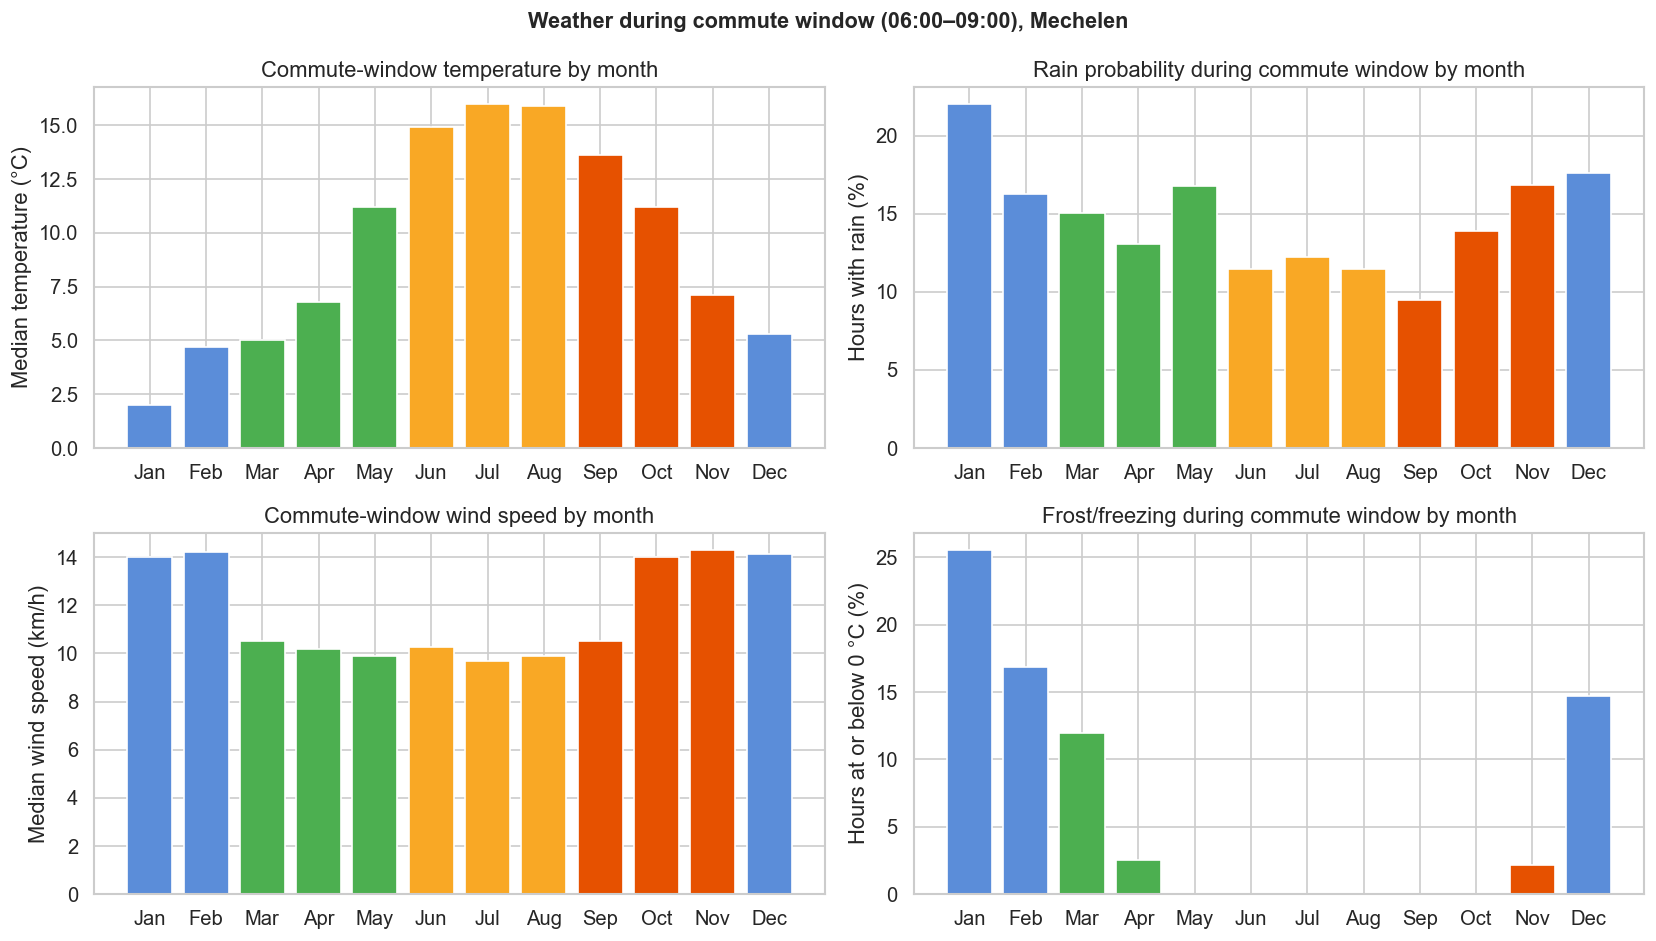

Business insight: Winter and autumn months show the highest rain probability and frost risk during commute hours — key drivers of traffic delays and train disruptions.


In [5]:
# Filter to the commute window hours 06:00–09:00
df_commute_window = df_weather[df_weather["hour"].isin([6, 7, 8, 9])].copy()

# Add month name and season
season_map = {12:"Winter",1:"Winter",2:"Winter",
              3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",
              9:"Autumn",10:"Autumn",11:"Autumn"}
df_commute_window["season"] = df_commute_window["month"].map(season_map)
df_commute_window["month_name"] = pd.to_datetime(
    df_commute_window["date"].astype(str)).dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Temperature by month
temp_by_month = df_commute_window.groupby("month_name")["temperature_2m"].median().reindex(month_order)
axes[0,0].bar(month_order, temp_by_month.values,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[0,0].axhline(0, color="black", ls="--", lw=0.8)
axes[0,0].set_ylabel("Median temperature (°C)")
axes[0,0].set_title("Commute-window temperature by month")

# Rain probability by month
rain_prob = df_commute_window.groupby("month_name")["precipitation"].apply(
    lambda s: (s > 0).mean()).reindex(month_order)
axes[0,1].bar(month_order, rain_prob.values * 100,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[0,1].set_ylabel("Hours with rain (%)")
axes[0,1].set_title("Rain probability during commute window by month")

# Wind by month
wind_by_month = df_commute_window.groupby("month_name")["wind_speed_10m"].median().reindex(month_order)
axes[1,0].bar(month_order, wind_by_month.values,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[1,0].set_ylabel("Median wind speed (km/h)")
axes[1,0].set_title("Commute-window wind speed by month")

# Snow / frost days
frost = df_commute_window.groupby("month_name")["temperature_2m"].apply(
    lambda s: (s <= 0).mean()).reindex(month_order)
axes[1,1].bar(month_order, frost.values * 100,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[1,1].set_ylabel("Hours at or below 0 °C (%)")
axes[1,1].set_title("Frost/freezing during commute window by month")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Weather during commute window (06:00–09:00), Mechelen", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_commute_window_weather.png", bbox_inches="tight")
plt.show()

print("Business insight: Winter and autumn months show the highest rain probability and frost risk during "
      "commute hours — key drivers of traffic delays and train disruptions.")

### 1c. Weather by weekday — do Mondays have worse weather?

C:\Users\mmylle\AppData\Local\Temp\ipykernel_40336\3058154774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cw_wd, x="weekday", y="temperature_2m",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_40336\3058154774.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rainy, x="weekday", y="precipitation",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_40336\3058154774.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cw_wd, x="weekday", y="wind_speed_10m",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_40336\3058154774.p

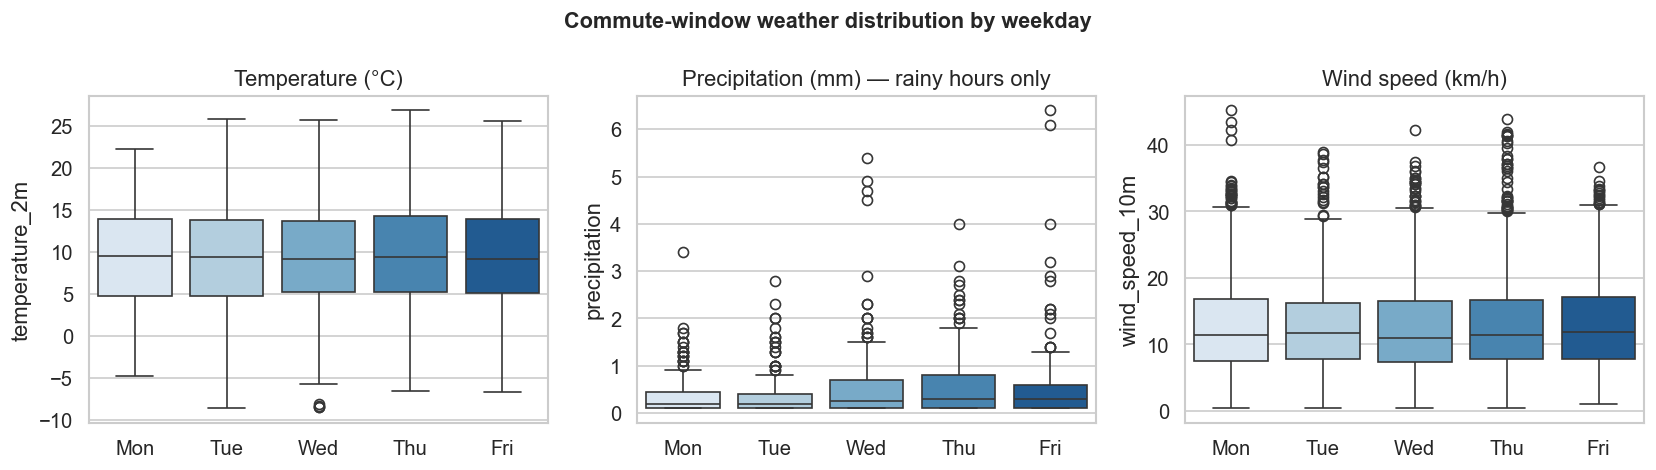

Business insight: Weather distributions are nearly uniform across weekdays — day-of-week traffic patterns are NOT driven by weather alone.


In [6]:
df_cw_wd = df_commute_window[df_commute_window["weekday"].isin(WEEKDAY_ORDER)].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Temperature
sns.boxplot(data=df_cw_wd, x="weekday", y="temperature_2m",
            order=WEEKDAY_ORDER, ax=axes[0], palette="Blues")
axes[0].set_title("Temperature (°C)")
axes[0].set_xlabel("")

# Precipitation (only rainy hours to avoid zero-inflation)
rainy = df_cw_wd[df_cw_wd["precipitation"] > 0]
sns.boxplot(data=rainy, x="weekday", y="precipitation",
            order=WEEKDAY_ORDER, ax=axes[1], palette="Blues")
axes[1].set_title("Precipitation (mm) — rainy hours only")
axes[1].set_xlabel("")

# Wind speed
sns.boxplot(data=df_cw_wd, x="weekday", y="wind_speed_10m",
            order=WEEKDAY_ORDER, ax=axes[2], palette="Blues")
axes[2].set_title("Wind speed (km/h)")
axes[2].set_xlabel("")

for ax in axes:
    ax.set_xticklabels([d[:3] for d in WEEKDAY_ORDER])

fig.suptitle("Commute-window weather distribution by weekday", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_weather_by_weekday.png", bbox_inches="tight")
plt.show()

print("Business insight: Weather distributions are nearly uniform across weekdays — "
      "day-of-week traffic patterns are NOT driven by weather alone.")

---
## 2. Belgian Workdays Calendar

We build a complete calendar (2021 → today + 2 future years) that classifies each day as:
- weekday or weekend
- Belgian public holiday or not
- working day (Mon–Fri, excluding public holidays)
- season, school period indicator (heuristic)

In [7]:
def build_be_calendar(start_year: int = 2021, end_year: int = None) -> pd.DataFrame:
    if end_year is None:
        end_year = date.today().year + 2

    be_hol = holidays.country_holidays("BE", years=range(start_year, end_year + 1))

    dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq="D")
    df = pd.DataFrame({"date": dates})

    df["weekday"]     = df["date"].dt.day_name()
    df["weekday_num"] = df["date"].dt.weekday          # 0=Mon … 4=Fri
    df["month"]       = df["date"].dt.month
    df["year"]        = df["date"].dt.year
    df["iso_week"]    = df["date"].dt.isocalendar().week.astype(int)

    df["is_weekend"]  = df["weekday_num"] >= 5
    df["is_holiday"]  = df["date"].dt.date.astype("O").isin(be_hol)
    df["holiday_name"] = df["date"].dt.date.astype("O").map(lambda d: be_hol.get(d, ""))
    df["is_workday"]  = ~df["is_weekend"] & ~df["is_holiday"]

    season_map = {12:"Winter",1:"Winter",2:"Winter",
                  3:"Spring",4:"Spring",5:"Spring",
                  6:"Summer",7:"Summer",8:"Summer",
                  9:"Autumn",10:"Autumn",11:"Autumn"}
    df["season"] = df["month"].map(season_map)

    # Heuristic Belgian school periods (July + August = school holidays)
    df["is_school_holiday"] = df["month"].isin([7, 8])

    return df


calendar_path = RAW / "calendar_be.csv"
df_calendar = build_be_calendar()
df_calendar.to_csv(calendar_path, index=False)

hist_workdays = df_calendar[
    df_calendar["is_workday"] & (df_calendar["date"].dt.date <= date.today())
]
print(f"Calendar: {len(df_calendar):,} days total")
print(f"Historical workdays (up to today): {len(hist_workdays):,}")
print(f"Public holidays per year:")
print(df_calendar[df_calendar["is_holiday"]].groupby("year").size().to_string())
df_calendar.head(10)

Calendar: 2,922 days total
Historical workdays (up to today): 1,375
Public holidays per year:
year
2021    12
2022    12
2023    12
2024    12
2025    12
2026    12
2027    12
2028    12


,date,weekday,weekday_num,month,year,iso_week,is_weekend,is_holiday,holiday_name,is_workday,season,is_school_holiday
0,2021-01-01,Friday,4,1,2021,53,False,True,Nieuwjaar,False,Winter,False
1,2021-01-02,Saturday,5,1,2021,53,True,False,,False,Winter,False
2,2021-01-03,Sunday,6,1,2021,53,True,False,,False,Winter,False
3,2021-01-04,Monday,0,1,2021,1,False,False,,True,Winter,False
4,2021-01-05,Tuesday,1,1,2021,1,False,False,,True,Winter,False
5,2021-01-06,Wednesday,2,1,2021,1,False,False,,True,Winter,False
6,2021-01-07,Thursday,3,1,2021,1,False,False,,True,Winter,False
7,2021-01-08,Friday,4,1,2021,1,False,False,,True,Winter,False
8,2021-01-09,Saturday,5,1,2021,1,True,False,,False,Winter,False
9,2021-01-10,Sunday,6,1,2021,1,True,False,,False,Winter,False


### 2a. Calendar EDA

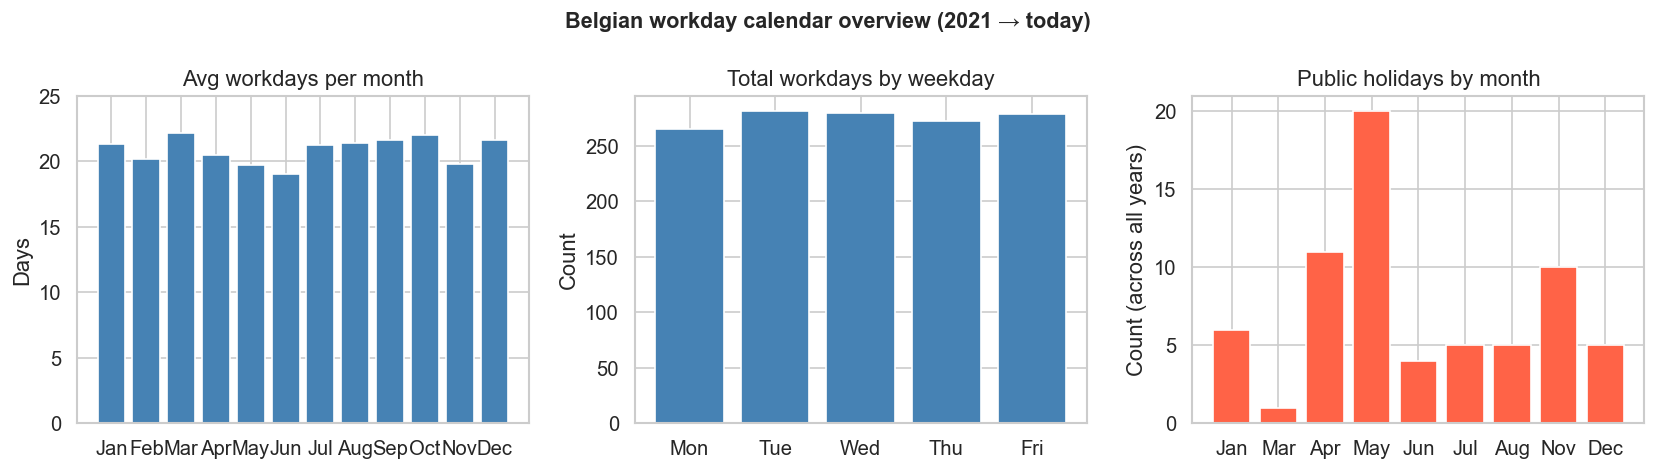

Business insight: May and November have the most public holidays, reducing office attendance and making those months lighter on commute pressure.


In [8]:
hist_cal = df_calendar[
    (df_calendar["date"].dt.year >= 2021) &
    (df_calendar["date"].dt.date <= date.today())
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Workdays per month
workdays_per_month = (
    hist_cal[hist_cal["is_workday"]]
    .groupby(["year", "month"])
    .size()
    .reset_index(name="n")
)
workdays_per_month["ym"] = workdays_per_month["year"].astype(str) + "-" + workdays_per_month["month"].astype(str).str.zfill(2)
workdays_per_month = workdays_per_month.sort_values("ym")
avg_per_month = workdays_per_month.groupby("month")["n"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].bar(month_names, avg_per_month.values, color="steelblue", edgecolor="white")
axes[0].set_title("Avg workdays per month")
axes[0].set_ylabel("Days")
axes[0].set_ylim(0, 25)

# Workdays per weekday
wd_counts = hist_cal[hist_cal["is_workday"]]["weekday"].value_counts().reindex(WEEKDAY_ORDER)
axes[1].bar([d[:3] for d in WEEKDAY_ORDER], wd_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("Total workdays by weekday")
axes[1].set_ylabel("Count")

# Holidays by month
hol_per_month = hist_cal[hist_cal["is_holiday"]]["month"].value_counts().sort_index()
axes[2].bar([month_names[m-1] for m in hol_per_month.index], hol_per_month.values,
            color="tomato", edgecolor="white")
axes[2].set_title("Public holidays by month")
axes[2].set_ylabel("Count (across all years)")

fig.suptitle("Belgian workday calendar overview (2021 → today)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_calendar_overview.png", bbox_inches="tight")
plt.show()

print("Business insight: May and November have the most public holidays, reducing office "
      "attendance and making those months lighter on commute pressure.")

---
## 3. Real Train Data — Infrabel Punctuality History

Instead of the iRail schedule approximation, we now use **real Infrabel data**: 
the official per-stop punctuality records published by Infrabel (Belgian rail 
infrastructure manager).

The index file `data/newdata/newtraindatasets.csv` lists 148 monthly CSV files 
(2014–2026). We download months from **2021 onwards**, filter to trains departing 
**Gent-Sint-Pieters** between 06:00–09:00, join with **Mechelen** arrivals on the 
same train, and aggregate to daily stats.

| Column | Meaning |
|---|---|
| `train_planned_journey_min` | Median scheduled journey time (timetable) |
| `train_actual_journey_min`  | Median real journey time including delays |
| `train_delay_arr_median_s`  | Median arrival delay at Mechelen (seconds) |
| `train_on_time_pct`         | Share of trains arriving ≤ 5 min late |
| `train_cancelled_pct`       | Share of trains scheduled to serve Mechelen that never arrived |

**Cancellation detection**: a train is counted as cancelled if it was *scheduled* 
to stop at Mechelen (`planned_arr` is not NaN) but never arrived there (`real_arr` 
is NaN). This covers both trains cancelled at Gent and trains cancelled en route. 
Trains whose route does not include Mechelen at all are excluded from the count.

**Note — `FORCE_REFRESH`**: set it to `True` in the cell below the first time you 
run after clearing the Infrabel caches, or whenever you want to reprocess from scratch.
The raw files are ~300 MB each; with 4 parallel workers the full download takes 
roughly ¼ of the sequential time. Once the caches are warm, subsequent runs are instant.

In [9]:
# ── Refresh control ───────────────────────────────────────────────────────────
# Set FORCE_REFRESH = True to delete all caches and re-download + reprocess
# every Infrabel monthly file.  Leave False for fast cached loading.
FORCE_REFRESH = True

import sys, os
sys.path.insert(0, os.getcwd())
from data_pipeline import fetch_infrabel_punctuality, CAR_PREF_BUFFER_MIN

if FORCE_REFRESH:
    import pathlib
    for f in pathlib.Path("data/raw/infrabel").glob("*.csv"):
        f.unlink()
    cached_combined = pathlib.Path("data/processed/infrabel_daily_commute.csv")
    if cached_combined.exists():
        cached_combined.unlink()
    print("Infrabel caches cleared — will re-download all monthly files.")

df_infrabel = fetch_infrabel_punctuality(force_refresh=FORCE_REFRESH)

if df_infrabel.empty:
    print("No Infrabel data loaded — check the index file path.")
else:
    print(f"Shape: {df_infrabel.shape}")
    print(f"Date range: {df_infrabel['date'].min().date()} -> {df_infrabel['date'].max().date()}")
    missing = df_infrabel.isnull().sum()
    missing = missing[missing > 0]
    print(f"\nMissing values:\n{missing.to_string() if len(missing) else 'None'}")
    print(f"\nOverall cancellation rate : {df_infrabel['train_cancelled_pct'].mean():.2%}")
    print(f"Overall on-time rate      : {df_infrabel['train_on_time_pct'].mean():.2%}")
    display(df_infrabel.head(10))

Infrabel caches cleared — will re-download all monthly files.
[train_real] Processing 64 monthly Infrabel files (2021+) …
  [2021-01] Downloading …  [2021-02] Downloading …  [2021-03] Downloading …  [2021-04] Downloading … 297,275 KB → 28 days
  [2021-05] Downloading … 320,596 KB → 31 days
  [2021-06] Downloading … 286,394 KB → 28 days
  [2021-07] Downloading … 304,014 KB 312,952 KB parse error: Error tokenizing data. C error: out of memory
  [2021-08] Downloading … → 31 days
  [2021-09] Downloading … 315,258 KB → 26 days
  [2021-10] Downloading … 291,914 KB → 31 days
  [2021-11] Downloading … 302,699 KB 311,131 KB → 31 days
  [2021-12] Downloading … → 30 days
  [2022-01] Downloading … 314,021 KB → 31 days
  [2022-02] Downloading … 301,986 KB → 28 days
  [2022-03] Downloading … 322,620 KB → 29 days
  [2022-04] Downloading … 279,820 KB → 28 days
  [2022-05] Downloading … 314,567 KB → 29 days
  [2022-06] Downloading … 323,502 KB → 29 days
  [2022-07] Downloading … 311,357 KB 295,394 KB →

,date,n_trains,train_planned_journey_min,train_actual_journey_min,train_delay_arr_median_s,train_on_time_pct,train_cancelled_pct
0,2021-01-01,2,54.0,54.225000,3.0,1.000000,0.0
1,2021-01-02,2,54.0,53.458333,-33.0,1.000000,0.0
2,2021-01-03,2,54.0,54.008333,-17.0,1.000000,0.0
3,2021-01-04,6,58.0,57.541667,94.5,0.833333,0.0
4,2021-01-05,6,58.0,63.625000,50.5,0.833333,0.0
5,2021-01-06,6,58.0,57.050000,-35.5,1.000000,0.0
6,2021-01-07,6,58.0,58.791667,53.0,0.833333,0.0
7,2021-01-08,6,58.0,57.183333,0.5,1.000000,0.0
8,2021-01-09,8,37.0,38.683333,167.5,0.750000,0.0
9,2021-01-10,8,37.0,39.108333,98.0,0.875000,0.0


### 3a. Delay distribution and monthly on-time rate

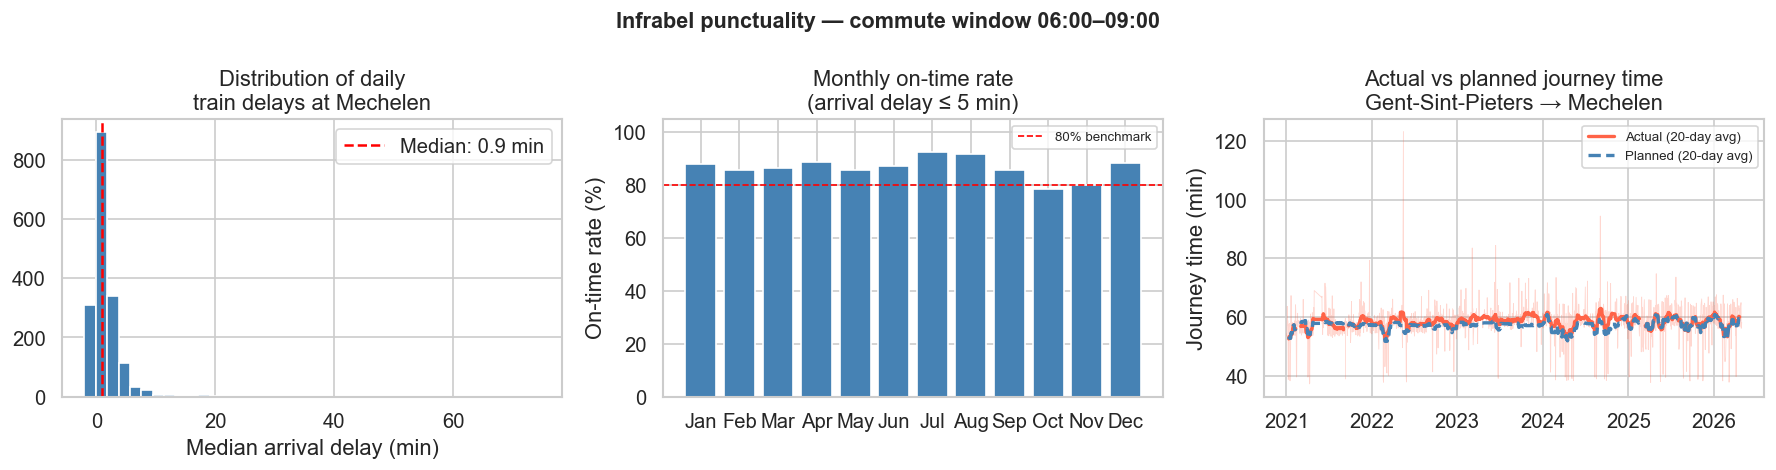

Days with median delay > 5 min : 5.8%
Overall average on-time rate   : 86.8%
Overall cancellation rate      : 0.0%


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if not df_infrabel.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Delay histogram
    delay_min = df_infrabel["train_delay_arr_median_s"].dropna() / 60
    axes[0].hist(delay_min, bins=40, color="steelblue", edgecolor="white")
    axes[0].axvline(delay_min.median(), color="red", ls="--", lw=1.5,
                    label=f"Median: {delay_min.median():.1f} min")
    axes[0].set_xlabel("Median arrival delay (min)")
    axes[0].set_title("Distribution of daily\ntrain delays at Mechelen")
    axes[0].legend()

    # On-time rate by calendar month
    df_infrabel["month"] = pd.to_datetime(df_infrabel["date"]).dt.month
    month_ot = df_infrabel.groupby("month")["train_on_time_pct"].mean()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]
    axes[1].bar([month_names[m-1] for m in month_ot.index],
                month_ot.values * 100, color="steelblue", edgecolor="white")
    axes[1].axhline(80, color="red", ls="--", lw=1, label="80% benchmark")
    axes[1].set_ylabel("On-time rate (%)")
    axes[1].set_title("Monthly on-time rate\n(arrival delay ≤ 5 min)")
    axes[1].set_ylim(0, 105)
    axes[1].legend(fontsize=8)

    # Actual vs planned journey time rolling average
    df_infrabel["date_dt"] = pd.to_datetime(df_infrabel["date"])
    df_sorted = df_infrabel.sort_values("date_dt")
    axes[2].plot(df_sorted["date_dt"], df_sorted["train_actual_journey_min"],
                 alpha=0.25, lw=0.5, color="tomato")
    axes[2].plot(df_sorted["date_dt"],
                 df_sorted["train_actual_journey_min"].rolling(20, center=True).mean(),
                 lw=2, color="tomato", label="Actual (20-day avg)")
    axes[2].plot(df_sorted["date_dt"],
                 df_sorted["train_planned_journey_min"].rolling(20, center=True).mean(),
                 lw=2, color="steelblue", ls="--", label="Planned (20-day avg)")
    axes[2].set_ylabel("Journey time (min)")
    axes[2].set_title("Actual vs planned journey time\nGent-Sint-Pieters → Mechelen")
    axes[2].legend(fontsize=8)

    fig.suptitle("Infrabel punctuality — commute window 06:00–09:00",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("data/processed/plot_infrabel_overview.png", bbox_inches="tight")
    plt.show()

    pct_late = (df_infrabel["train_delay_arr_median_s"] > 300).mean()
    print(f"Days with median delay > 5 min : {pct_late:.1%}")
    print(f"Overall average on-time rate   : {df_infrabel['train_on_time_pct'].mean():.1%}")
    print(f"Overall cancellation rate      : {df_infrabel['train_cancelled_pct'].mean():.1%}")


### 3b. Delay by weekday — are some days worse for trains?

C:\Users\mmylle\AppData\Local\Temp\ipykernel_40336\3759214836.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wd, x="weekday", y="delay_min",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_40336\3759214836.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([d[:3] for d in WEEKDAY_ORDER])


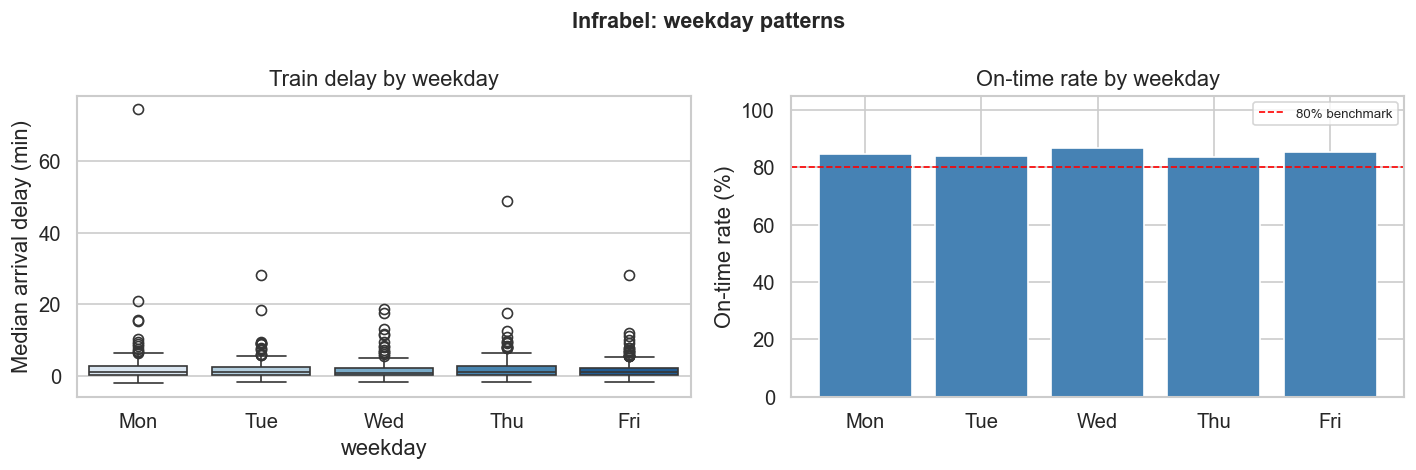

Insight: peak demand days (Tue/Thu) tend to show higher delays,
mirroring the car congestion pattern — both modes are stressed simultaneously.


In [11]:
if not df_infrabel.empty:
    WEEKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday"]
    df_infrabel["weekday"] = pd.to_datetime(df_infrabel["date"]).dt.day_name()
    df_wd = df_infrabel[df_infrabel["weekday"].isin(WEEKDAY_ORDER)].copy()
    df_wd["delay_min"] = df_wd["train_delay_arr_median_s"] / 60

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=df_wd, x="weekday", y="delay_min",
                order=WEEKDAY_ORDER, ax=axes[0], palette="Blues")
    axes[0].set_xticklabels([d[:3] for d in WEEKDAY_ORDER])
    axes[0].set_ylabel("Median arrival delay (min)")
    axes[0].set_title("Train delay by weekday")

    ot_wd = df_wd.groupby("weekday")["train_on_time_pct"].mean().reindex(WEEKDAY_ORDER)
    axes[1].bar([d[:3] for d in WEEKDAY_ORDER],
                ot_wd.values * 100, color="steelblue", edgecolor="white")
    axes[1].axhline(80, color="red", ls="--", lw=1, label="80% benchmark")
    axes[1].set_ylabel("On-time rate (%)")
    axes[1].set_title("On-time rate by weekday")
    axes[1].set_ylim(0, 105)
    axes[1].legend(fontsize=8)

    fig.suptitle("Infrabel: weekday patterns", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("data/processed/plot_infrabel_by_weekday.png", bbox_inches="tight")
    plt.show()
    print("Insight: peak demand days (Tue/Thu) tend to show higher delays,")
    print("mirroring the car congestion pattern — both modes are stressed simultaneously.")


---
## 4a. Car Route Baseline — OSRM

OSRM (Open Source Routing Machine) is a free routing engine based on OpenStreetMap. The public demo server requires no API key. It gives us:
- **Base (free-flow) travel time**: the theoretical minimum assuming no congestion
- **Route distance** in km

From the base time we derive **congestion-adjusted estimates** using published traffic research for Belgian highways:
- Monday and Tuesday/Thursday peaks add 15–25% to free-flow time during morning rush
- Rain adds ~5–8%, heavy rain ~12%, snow or ice ~20–30%
- These factors come from TomTom Traffic Index and Flemish traffic research (AWV).

We then build a **daily travel time estimate** combining the OSRM base time with weather + weekday factors.

In [12]:
def fetch_osrm_route(lon1: float, lat1: float, lon2: float, lat2: float) -> dict:
    """Get route info from OSRM public demo server (no API key required)."""
    coords = f"{lon1},{lat1};{lon2},{lat2}"
    url = f"https://router.project-osrm.org/route/v1/driving/{coords}"
    params = {"overview": "false", "annotations": "false"}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    route = r.json()["routes"][0]
    return {
        "distance_km":       round(route["distance"] / 1000, 2),
        "free_flow_min":     round(route["duration"] / 60, 1),
    }


route_cache = RAW / "osrm_route_gent_mechelen.json"

if route_cache.exists():
    with open(route_cache) as f:
        route_info = json.load(f)
    print("Loaded route from cache.")
else:
    print("Fetching route from OSRM...")
    route_info = fetch_osrm_route(LON_GENT, LAT_GENT, LON_MECHELEN, LAT_MECHELEN)
    with open(route_cache, "w") as f:
        json.dump(route_info, f)
    print("Saved to cache.")

FREE_FLOW_MIN  = route_info["free_flow_min"]
ROUTE_KM       = route_info["distance_km"]
print(f"\nGent-Sint-Pieters → Mechelen (via E40/R4):")
print(f"  Distance   : {ROUTE_KM} km")
print(f"  Free-flow  : {FREE_FLOW_MIN} min  (OSRM, no traffic)")
print(f"  Typical rush: ~{FREE_FLOW_MIN * 1.25:.0f}–{FREE_FLOW_MIN * 1.50:.0f} min (Tue/Thu morning peak)")

Loaded route from cache.

Gent-Sint-Pieters → Mechelen (via E40/R4):
  Distance   : 78.45 km
  Free-flow  : 59.5 min  (OSRM, no traffic)
  Typical rush: ~74–89 min (Tue/Thu morning peak)


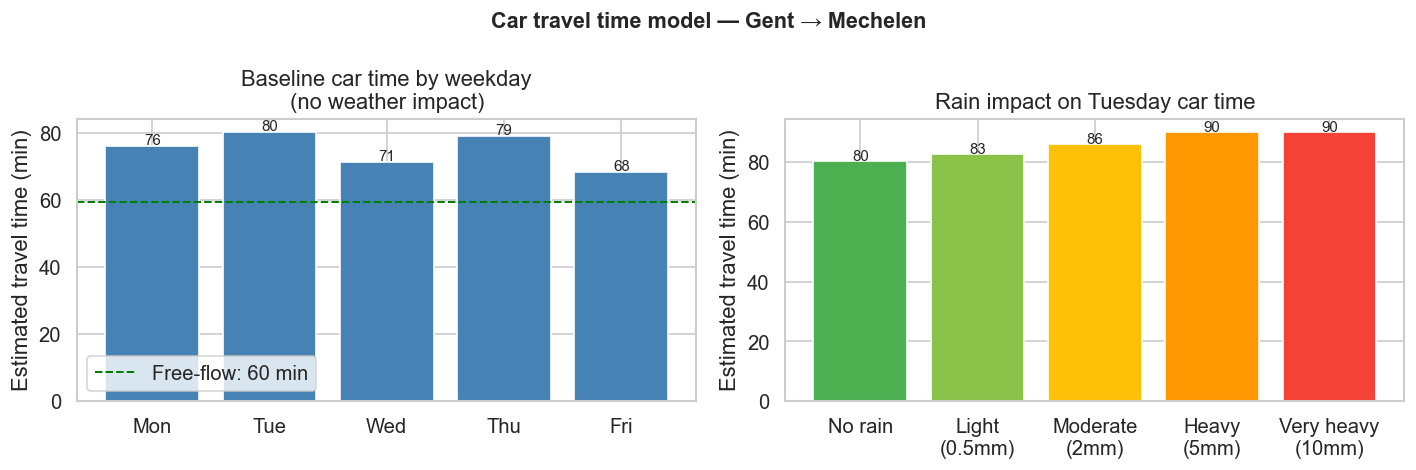

Free-flow baseline: 60 min
Worst case (heavy rain + Tue): 90 min
Best case (Fri, no rain): 68 min


In [13]:
# Build congestion multiplier table based on day-of-week and weather
# Sources: TomTom Traffic Index Belgium 2022-2024, AWV verkeersstudies

# Weekday congestion multipliers for 07:00-09:00 rush on the E40 corridor
WEEKDAY_CONGESTION = {
    "Monday":    1.28,   # post-weekend traffic build-up
    "Tuesday":   1.35,   # peak rush day
    "Wednesday": 1.20,
    "Thursday":  1.33,   # near peak
    "Friday":    1.15,   # lighter morning, heavier evening
}

def car_travel_time(row) -> float:
    """Estimate car travel time (min) from OSRM baseline + weather + weekday factors."""
    base = FREE_FLOW_MIN
    wd_mult = WEEKDAY_CONGESTION.get(row.get("weekday", "Wednesday"), 1.20)

    # Weather factors
    rain = row.get("rain_peak", 0) or 0
    wind = row.get("wind_peak", 0) or 0
    temp_min = row.get("temp_min", 10) or 10
    snow = row.get("snow_total", 0) or 0

    weather_mult = 1.0
    if rain >= 5:    weather_mult += 0.12
    elif rain >= 2:  weather_mult += 0.07
    elif rain >= 0.5: weather_mult += 0.03

    if snow >= 1:    weather_mult += 0.25
    if temp_min <= -3: weather_mult += 0.15
    elif temp_min <= 0: weather_mult += 0.07

    if wind >= 60:   weather_mult += 0.08
    elif wind >= 45: weather_mult += 0.04

    return round(base * wd_mult * weather_mult, 1)


# Visualize the congestion + weather sensitivity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weekday sensitivity
wd_times = {wd: round(FREE_FLOW_MIN * mult, 1) for wd, mult in WEEKDAY_CONGESTION.items()}
axes[0].bar([d[:3] for d in WEEKDAY_ORDER],
            [wd_times[d] for d in WEEKDAY_ORDER],
            color="steelblue", edgecolor="white")
axes[0].axhline(FREE_FLOW_MIN, color="green", ls="--", lw=1.2, label=f"Free-flow: {FREE_FLOW_MIN:.0f} min")
axes[0].set_ylabel("Estimated travel time (min)")
axes[0].set_title("Baseline car time by weekday\n(no weather impact)")
axes[0].legend()
for i, (wd, t) in enumerate([(d, wd_times[d]) for d in WEEKDAY_ORDER]):
    axes[0].text(i, t + 0.5, f"{t:.0f}", ha="center", fontsize=9)

# Weather sensitivity (for a typical Tuesday)
rain_vals  = [0, 0.5, 2, 5, 10]
base_tue   = FREE_FLOW_MIN * WEEKDAY_CONGESTION["Tuesday"]
rain_times = []
for r in rain_vals:
    mult = 1.0
    if r >= 5:    mult += 0.12
    elif r >= 2:  mult += 0.07
    elif r >= 0.5: mult += 0.03
    rain_times.append(round(base_tue * mult, 1))

labels = ["No rain", "Light\n(0.5mm)", "Moderate\n(2mm)", "Heavy\n(5mm)", "Very heavy\n(10mm)"]
bars = axes[1].bar(labels, rain_times, color=["#4caf50","#8bc34a","#ffc107","#ff9800","#f44336"], edgecolor="white")
axes[1].set_ylabel("Estimated travel time (min)")
axes[1].set_title("Rain impact on Tuesday car time")
for bar, t in zip(bars, rain_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{t:.0f}", ha="center", fontsize=9)

fig.suptitle("Car travel time model — Gent → Mechelen", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_car_travel_model.png", bbox_inches="tight")
plt.show()

print(f"Free-flow baseline: {FREE_FLOW_MIN:.0f} min")
print(f"Worst case (heavy rain + Tue): {round(FREE_FLOW_MIN * 1.35 * 1.12, 0):.0f} min")
print(f"Best case (Fri, no rain): {round(FREE_FLOW_MIN * 1.15, 0):.0f} min")

## 4b. Travelling time from the 'Vlaams Verkeercentrum'

Traffic indicators are available from the ['Vlaams Verkeercentrum'](https://indicatoren.verkeerscentrum.be/vc.indicators.web.gui/indicator/index#) website. The time to travel ('reistijd') from Gent to Mechelen is downloaded in the website directly:  
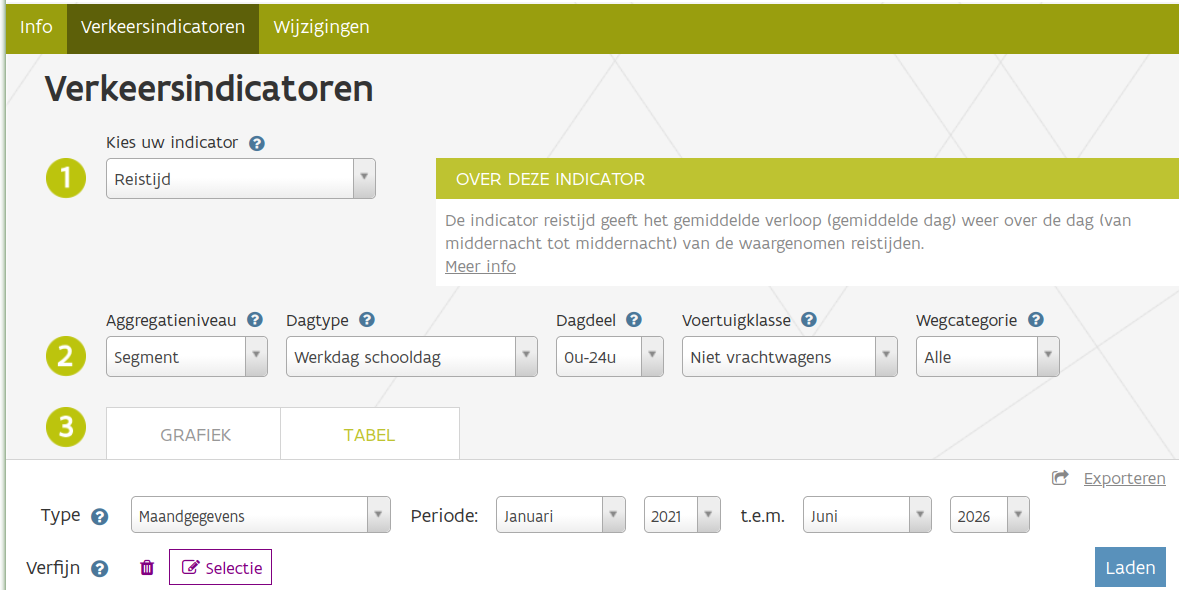
Note: The road segments annotations are described in the [Info](https://indicatoren.verkeerscentrum.be/vc.indicators.web.gui/indicator/index) page of the website.  
One drawback of this dataset is that the data is aggregated over all days of the week (Monday to Friday school days).

The following highways/crosspoints ('Knop') are used, resulting in the selection of the following road segments: 
1. from Gent to Antwerpen: E17 (A14):
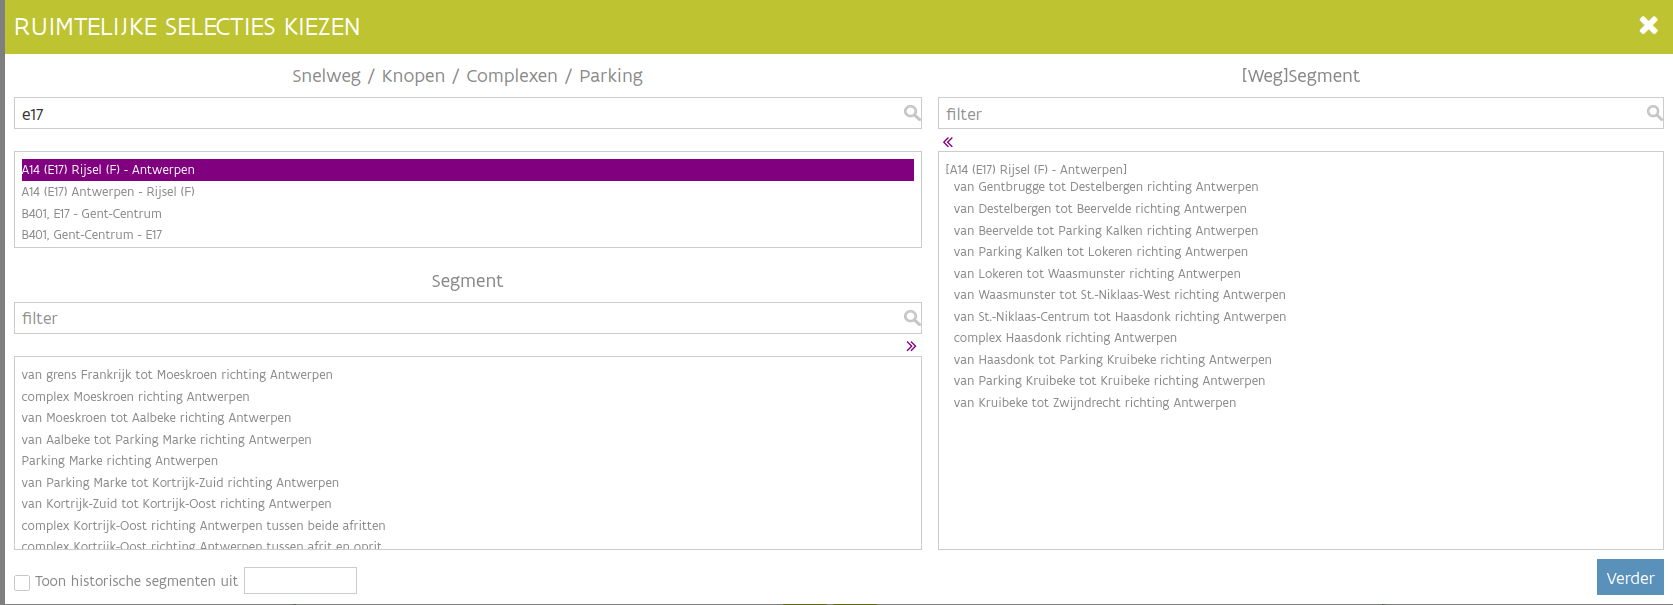
3. Ring of Antwerpen (R1): from Antwerpen-West (AW) to Antwerpen-Zuid (ANZ)
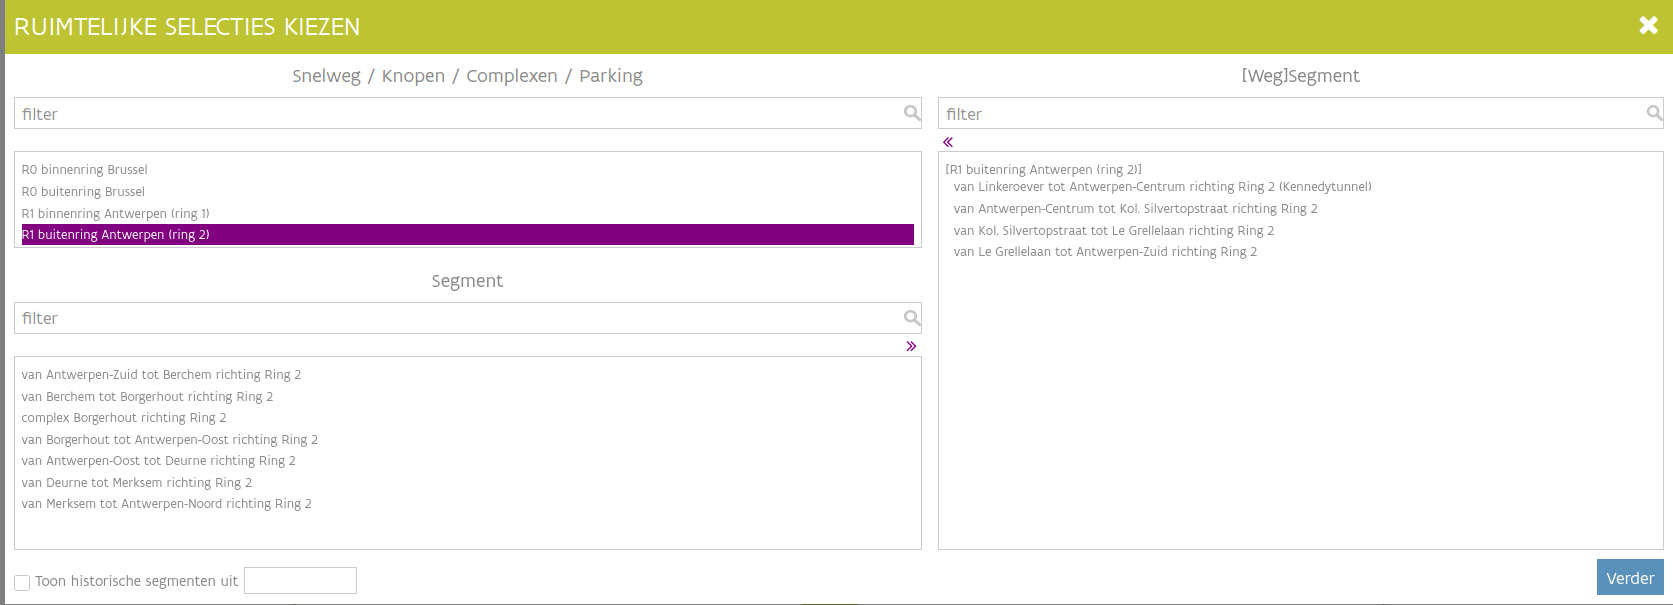
5. from Antwerpen to Mechelen: E19
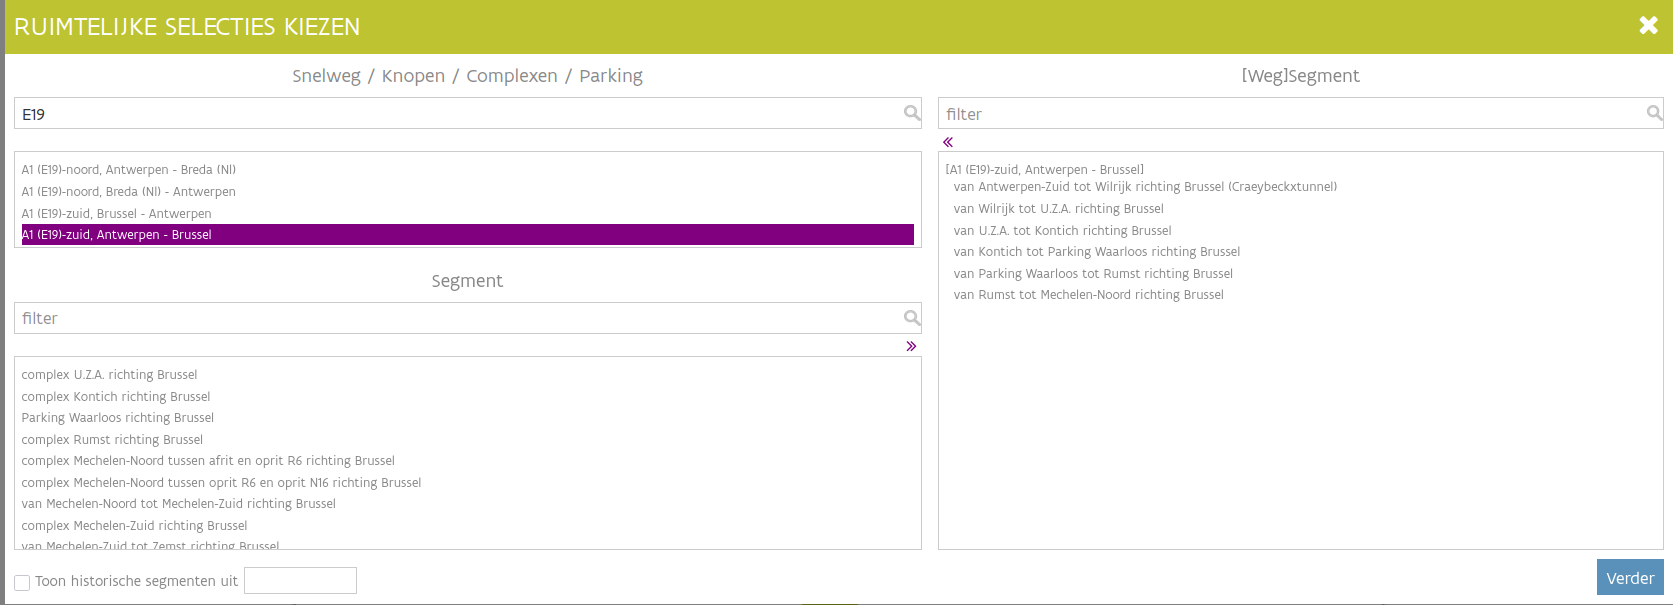

(The data is extracted in multiple times to avoid the error: `504 Gateway Time-out`.)

In [14]:
dir = './data/raw/'
import os
data_traffic_list = []
for file in os.listdir(dir):
    if file.startswith("reistijd"):
        # print(file)
        data_traffic = pd.read_excel(io = os.path.join(dir, file), sheet_name = 'data')
        data_traffic_list.append(data_traffic)
data_traffic = pd.concat(data_traffic_list)

c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [15]:
data_traffic.head(1)

,jaar,maand,omschrijving,segmentnaam,tijdstip,gem_reistijd_auto
0,2024,1,A14 (E17) Rijsel (F) - Antwerpen,van Gentbrugge tot Destelbergen richting Antwe...,09:30,2.73


In [16]:
# extract hour
data_traffic['tijdstip_hour'] = data_traffic['tijdstip'].str.extract(r"(\d{2})")
data_traffic['tijdstip_hour'] = pd.to_numeric(data_traffic['tijdstip_hour'])

# filter data for peak hours: 6h -> 9h
data_traffic = data_traffic.loc[data_traffic['tijdstip_hour'].isin([6, 7, 8, 9])]

In [17]:
# sum travelling time across all segments
data_traffic_agg = data_traffic.groupby(['jaar', 'maand', 'omschrijving', 'tijdstip', 'tijdstip_hour'])['gem_reistijd_auto'].sum().reset_index()

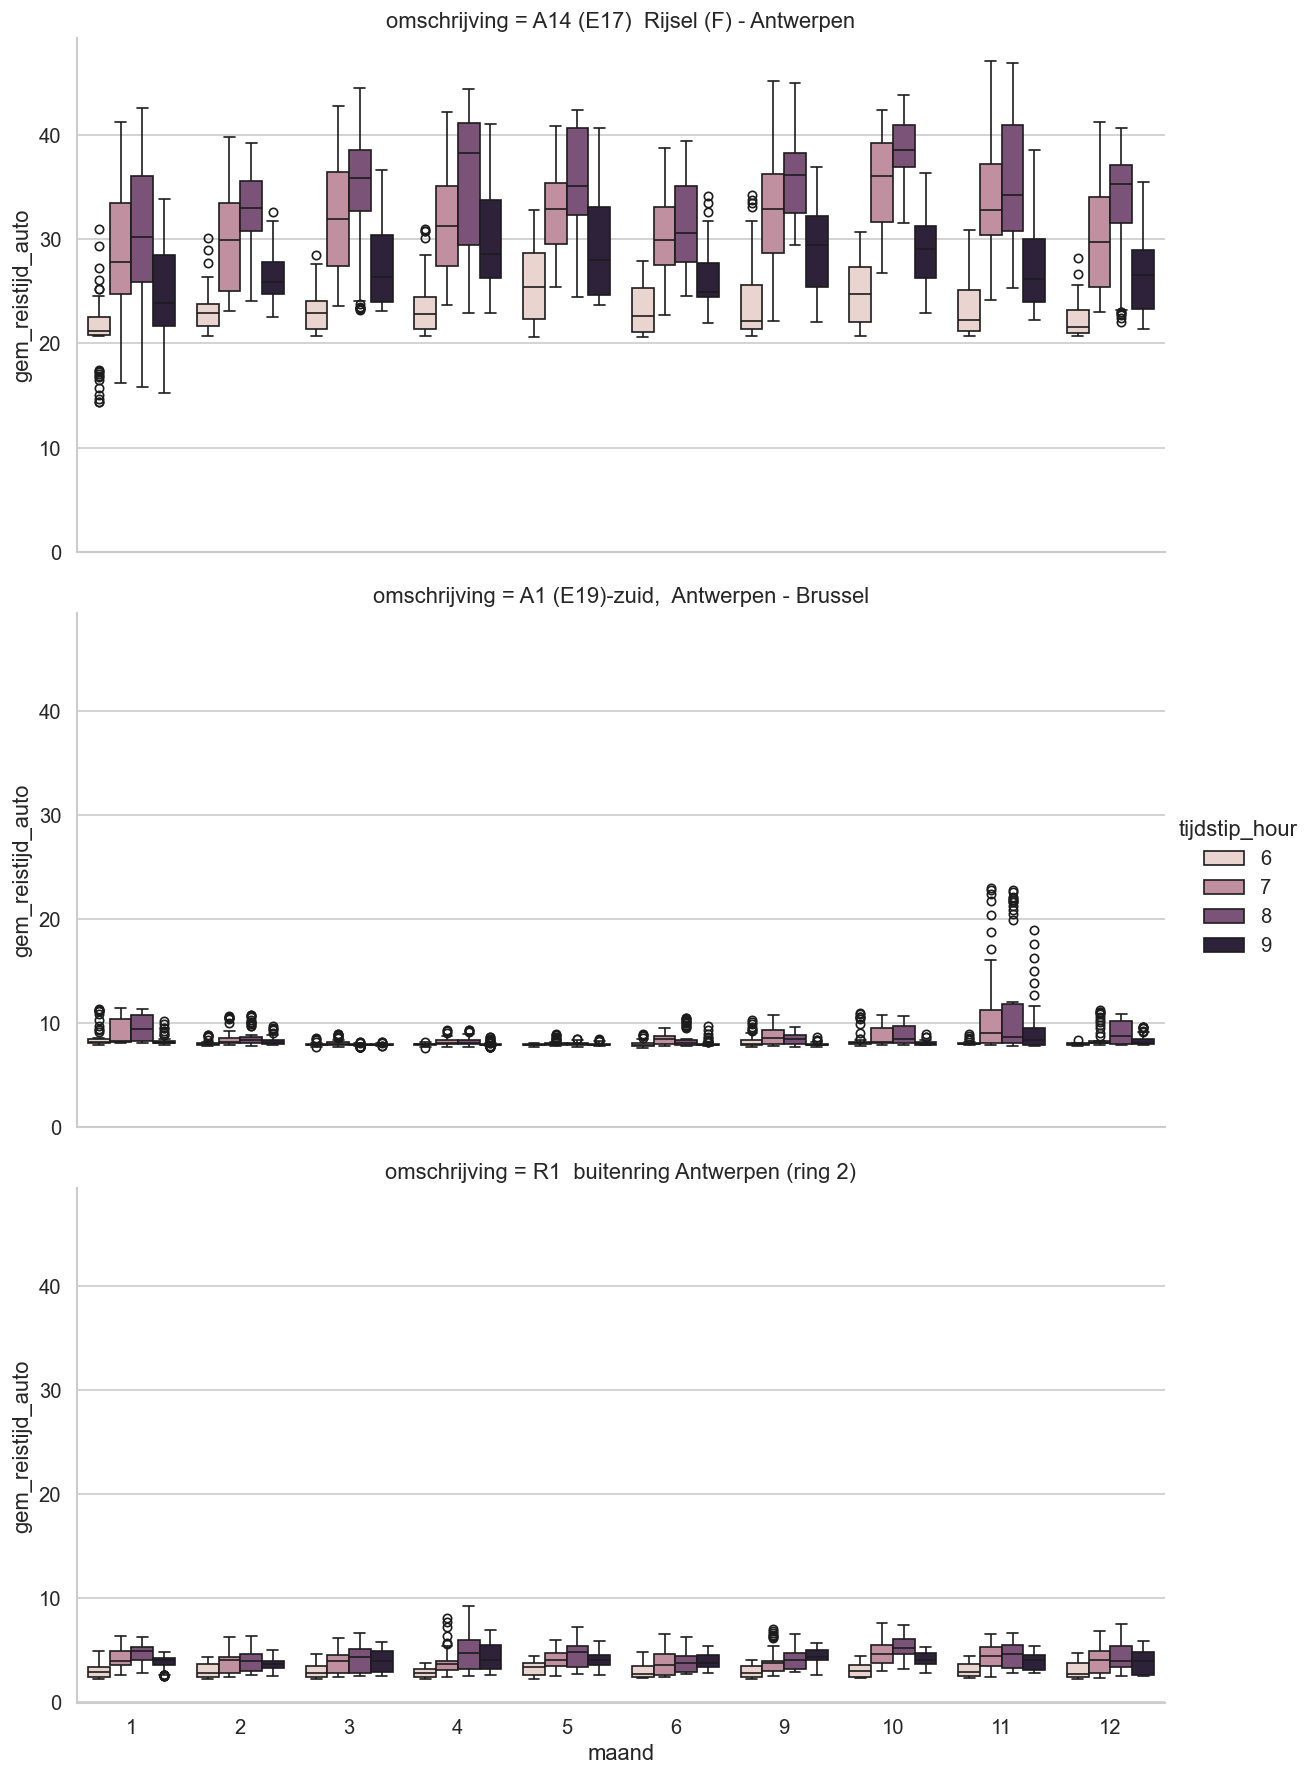

In [18]:
sns.catplot(
    data = data_traffic_agg, x = 'maand', y = 'gem_reistijd_auto', hue = 'tijdstip_hour',
    row = "omschrijving", kind = 'box', height = 5, aspect = 2
)
#sns.boxplot(data = data_traffic_agg, x = 'maand', y = 'gem_reistijd_auto', hue = 'omschrijving', ax = ax)

---
## 5. Cross-source EDA — Weather × Car × Train patterns

Before combining, let's look at patterns that cross data sources.

In [19]:
# Build daily commute-window weather features for workdays only
# (the building block we'll extend in section 6)

df_cw = df_weather[
    df_weather["hour"].isin([6, 7, 8, 9])
].copy()

df_cw_daily = (
    df_cw.groupby("date").agg(
        rain_total   = ("precipitation",        "sum"),
        rain_peak    = ("precipitation",        "max"),
        wind_peak    = ("wind_speed_10m",       "max"),
        wind_mean    = ("wind_speed_10m",       "mean"),
        temp_min     = ("temperature_2m",       "min"),
        temp_mean    = ("temperature_2m",       "mean"),
        humidity_max = ("relative_humidity_2m", "max"),
        snow_total   = ("snowfall",             "sum"),
    )
    .reset_index()
)
df_cw_daily["date"] = pd.to_datetime(df_cw_daily["date"])

# Merge with calendar to keep only historical workdays
df_cal_hist = df_calendar[
    df_calendar["is_workday"] &
    (df_calendar["date"].dt.date <= date.today())
][["date","weekday","weekday_num","month","year","season","is_school_holiday"]].copy()

df_work = df_cal_hist.merge(df_cw_daily, on="date", how="left")

# Apply car travel time model
df_work["car_est_min"] = df_work.apply(car_travel_time, axis=1)

# Add scheduled train time from real Infrabel data (median planned journey)
if not df_infrabel.empty:
    median_train_min = df_infrabel["train_planned_journey_min"].median()
else:
    median_train_min = 65.0   # fallback: ~65 min (Gent-Sint-Pieters -> Mechelen)

df_work["train_sched_min"] = median_train_min

print(f"Median scheduled train time: {median_train_min:.0f} min")
print(f"\nWorkday data shape: {df_work.shape}")
print(f"Workdays: {df_work['date'].min().date()} -> {df_work['date'].max().date()}")
df_work.head()


Median scheduled train time: 58 min

Workday data shape: (1375, 17)
Workdays: 2021-01-04 -> 2026-06-11


,date,weekday,weekday_num,month,year,season,is_school_holiday,rain_total,rain_peak,wind_peak,wind_mean,temp_min,temp_mean,humidity_max,snow_total,car_est_min,train_sched_min
0,2021-01-04,Monday,0,1,2021,Winter,False,0.7,0.3,15.5,15.225,1.8,1.850,97.0,0.00,76.2,58.0
1,2021-01-05,Tuesday,1,1,2021,Winter,False,0.1,0.1,13.8,13.000,1.8,1.825,96.0,0.00,80.3,58.0
2,2021-01-06,Wednesday,2,1,2021,Winter,False,1.2,0.5,14.3,13.900,2.3,2.400,98.0,0.00,73.5,58.0
3,2021-01-07,Thursday,3,1,2021,Winter,False,0.8,0.3,14.4,13.575,0.9,1.125,99.0,0.07,79.1,58.0
4,2021-01-08,Friday,4,1,2021,Winter,False,0.4,0.1,18.8,17.825,1.6,1.750,94.0,0.00,68.4,58.0


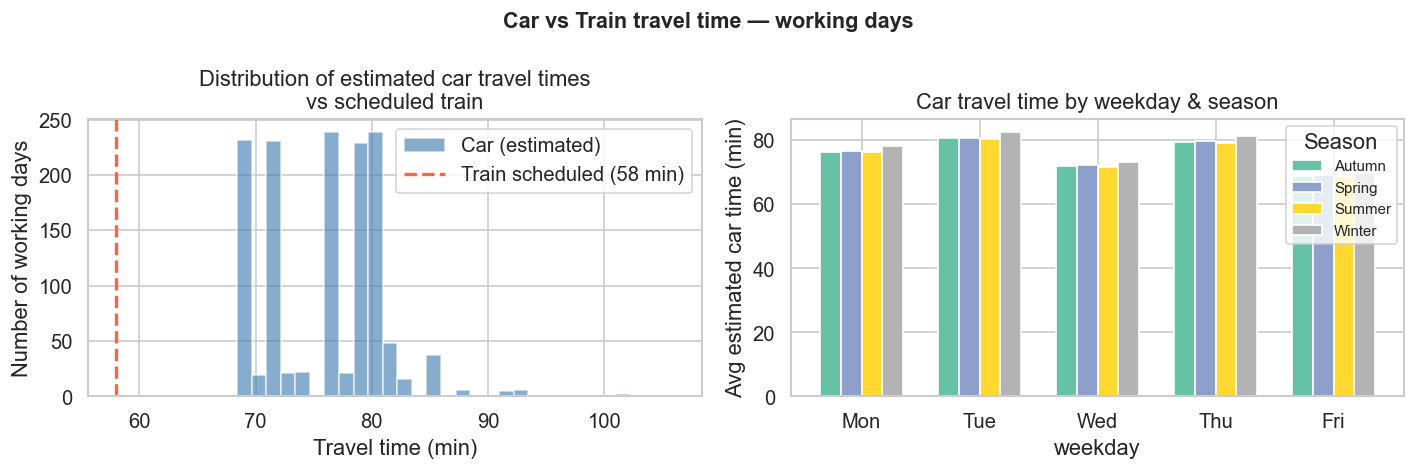

Days where car is estimated faster than train: 0%
Business insight: Car is faster on light-traffic days; train becomes competitive or preferred on peak rush days and bad weather.


In [20]:
# Car vs train estimated time — distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram comparison
axes[0].hist(df_work["car_est_min"], bins=30, alpha=0.65, color="steelblue", label="Car (estimated)")
axes[0].axvline(median_train_min, color="tomato", lw=2, ls="--", label=f"Train scheduled ({median_train_min:.0f} min)")
axes[0].set_xlabel("Travel time (min)")
axes[0].set_ylabel("Number of working days")
axes[0].set_title("Distribution of estimated car travel times\nvs scheduled train")
axes[0].legend()

# Car time by weekday × season
pivot = df_work.groupby(["weekday","season"])["car_est_min"].mean().unstack()
pivot = pivot.reindex(WEEKDAY_ORDER)
pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white", width=0.7)
axes[1].set_xticklabels([d[:3] for d in WEEKDAY_ORDER], rotation=0)
axes[1].set_ylabel("Avg estimated car time (min)")
axes[1].set_title("Car travel time by weekday & season")
axes[1].legend(title="Season", fontsize=9)

fig.suptitle("Car vs Train travel time — working days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_car_vs_train.png", bbox_inches="tight")
plt.show()

pct_car_faster = (df_work["car_est_min"] <= df_work["train_sched_min"]).mean() * 100
print(f"Days where car is estimated faster than train: {pct_car_faster:.0f}%")
print("Business insight: Car is faster on light-traffic days; "
      "train becomes competitive or preferred on peak rush days and bad weather.")

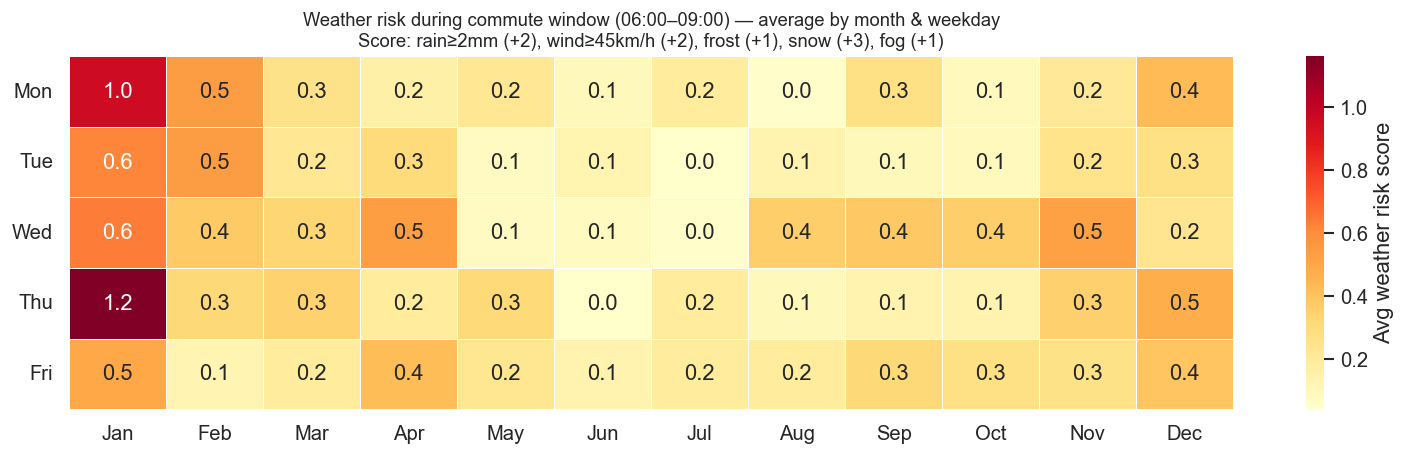

Business insight: January–February and November–December show consistently higher weather risk. No single weekday has systematically worse weather — any perceived weekday risk is driven by traffic patterns, not weather.


In [21]:
# Weather-risk heatmap: month × weekday
# Risk score = normalized sum of weather-impact factors during commute window

df_work["weather_risk"] = (
    (df_work["rain_peak"] >= 2).astype(int) * 2
    + (df_work["wind_peak"] >= 45).astype(int) * 2
    + (df_work["temp_min"] <= 0).astype(int) * 1
    + (df_work["snow_total"] > 0).astype(int) * 3
    + (df_work["humidity_max"] >= 97).astype(int) * 1
)

month_names_full = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]
heatmap_data = (
    df_work.groupby(["weekday", "month"])["weather_risk"]
    .mean()
    .unstack("month")
    .reindex(WEEKDAY_ORDER)
)
heatmap_data.columns = [month_names_full[c-1] for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg weather risk score"},
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticklabels([d[:3] for d in WEEKDAY_ORDER], rotation=0)
ax.set_title(
    "Weather risk during commute window (06:00–09:00) — average by month & weekday\n"
    "Score: rain≥2mm (+2), wind≥45km/h (+2), frost (+1), snow (+3), fog (+1)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("data/processed/plot_weather_risk_heatmap.png", bbox_inches="tight")
plt.show()

print("Business insight: January–February and November–December show consistently higher "
      "weather risk. No single weekday has systematically worse weather — any perceived "
      "weekday risk is driven by traffic patterns, not weather.")

---
## 6. Combine All Sources — Final Working DataFrame

All data sources merged into a single **daily-level workday DataFrame**.

| Column group | Source |
|---|---|
| `date`, `weekday`, `month`, `season` | calendar |
| `is_school_holiday` | calendar |
| `rain_*`, `wind_*`, `temp_*`, `snow_total`, `humidity_max` | Open-Meteo |
| `weather_risk` | derived composite score |
| `car_est_min` | OSRM + weekday/weather factors |
| `train_planned_journey_min` | **Infrabel** (real timetable) |
| `train_actual_journey_min`  | **Infrabel** (real including delays) |
| `train_delay_arr_median_s`  | **Infrabel** (median delay in seconds) |
| `train_on_time_pct`         | **Infrabel** (share on time) |
| `train_cancelled_pct`       | **Infrabel** (share cancelled) |
| `car_faster_than_train`     | derived binary target |


In [22]:
# build_combined_df() handles all fetching, caching, and merging internally.
# FORCE_REFRESH is set in section 3 above; True forces a full rebuild.
from data_pipeline import build_combined_df, CAR_PREF_BUFFER_MIN

df_combined = build_combined_df(force_refresh=FORCE_REFRESH)

print(f"Shape: {df_combined.shape}")
print(f"Date range: {df_combined['date'].min().date()} -> {df_combined['date'].max().date()}")
print(f"Car preference buffer      : {CAR_PREF_BUFFER_MIN} min  (car chosen if ≤ train + buffer)")
missing = df_combined.isnull().sum()
missing = missing[missing > 0]
print(f"\nMissing values:\n{missing.to_string() if len(missing) else 'None'}")
df_combined.head(10)

[pipeline] Building combined dataset from scratch …

[weather] Loading from cache: data\raw\weather_mechelen_hourly.csv
[calendar] Loading from cache: data\raw\calendar_be.csv
[train] Loading from cache: data\raw\irail_connections_sample.csv
[car] Loading route from cache: data\raw\osrm_route_gent_mechelen.json

[pipeline] Aggregating weather to daily commute-window features …
[pipeline] Filtering to Belgian working days …
[pipeline] Estimating car travel times …
[pipeline] Loading real Infrabel train data …
[train_real] Processing 64 monthly Infrabel files (2021+) …
  [2021-01] Downloading …  [2021-02] Downloading …  [2021-03] Downloading …  [2021-04] Downloading … 286,394 KB 297,275 KB → 28 days
  [2021-05] Downloading … → 28 days
  [2021-06] Downloading … 320,596 KB → 31 days
 312,952 KB  [2021-07] Downloading … → 31 days
  [2021-08] Downloading … 304,014 KB → 22 days
  [2021-09] Downloading … 315,258 KB → 26 days
  [2021-10] Downloading … 302,699 KB → 31 days
  [2021-11] Downloadin

,date,weekday,weekday_num,month,year,season,is_school_holiday,is_mon,is_tue_thu,is_fri,...,snow_total,weather_risk,car_est_min,train_planned_journey_min,train_actual_journey_min,train_delay_arr_median_s,train_on_time_pct,train_cancelled_pct,train_sched_min,car_faster_than_train
0,2021-01-04,Monday,0,1,2021,Winter,False,1,0,0,...,0.00,1,76.2,58.0,57.541667,94.5,0.833333,0.0,58.0,0
1,2021-01-05,Tuesday,1,1,2021,Winter,False,0,1,0,...,0.00,0,80.3,58.0,63.625000,50.5,0.833333,0.0,58.0,0
2,2021-01-06,Wednesday,2,1,2021,Winter,False,0,0,0,...,0.00,1,73.5,58.0,57.050000,-35.5,1.000000,0.0,58.0,0
3,2021-01-07,Thursday,3,1,2021,Winter,False,0,1,0,...,0.07,4,79.1,58.0,58.791667,53.0,0.833333,0.0,58.0,0
4,2021-01-08,Friday,4,1,2021,Winter,False,0,0,1,...,0.00,0,68.4,58.0,57.183333,0.5,1.000000,0.0,58.0,0
5,2021-01-11,Monday,0,1,2021,Winter,False,1,0,0,...,0.00,0,76.2,58.0,57.566667,6.0,1.000000,0.0,58.0,0
6,2021-01-12,Tuesday,1,1,2021,Winter,False,0,1,0,...,0.00,2,85.9,58.0,56.908333,-42.0,1.000000,0.0,58.0,0
7,2021-01-13,Wednesday,2,1,2021,Winter,False,0,0,0,...,0.00,0,71.4,58.0,57.083333,21.5,1.000000,0.0,58.0,0
8,2021-01-14,Thursday,3,1,2021,Winter,False,0,1,0,...,1.12,4,101.3,58.0,57.725000,-21.5,1.000000,0.0,58.0,0
9,2021-01-15,Friday,4,1,2021,Winter,False,0,0,1,...,0.00,1,73.2,58.0,57.791667,-33.0,0.833333,0.0,58.0,0


In [23]:
print("=" * 65)
print("COMBINED DATASET SUMMARY")
print("=" * 65)
print(f"Total workdays              : {len(df_combined):,}")
print(f"Date range                  : {df_combined['date'].min().date()} -> {df_combined['date'].max().date()}")
print()
print("Weather (median workday, 06-09h window):")
print(f"  Rain peak (mm)            : {df_combined['rain_peak'].median():.2f}")
print(f"  Wind peak (km/h)          : {df_combined['wind_peak'].median():.1f}")
print(f"  Temp min (C)              : {df_combined['temp_min'].median():.1f}")
print(f"  Days with rain            : {(df_combined['rain_peak'] > 0).mean():.1%}")
print(f"  Days with frost           : {(df_combined['temp_min'] <= 0).mean():.1%}")
print(f"  Days with snow            : {(df_combined['snow_total'] > 0).mean():.1%}")
print()
print("Train data (real Infrabel):")
has_real = df_combined["train_delay_arr_median_s"].notna()
print(f"  Days with Infrabel data   : {has_real.sum():,} / {len(df_combined):,} ({has_real.mean():.1%})")
print(f"  Planned journey (median)  : {df_combined['train_planned_journey_min'].median():.0f} min")
print(f"  Actual  journey (median)  : {df_combined['train_actual_journey_min'].median():.0f} min")
print(f"  Median delay at Mechelen  : {df_combined['train_delay_arr_median_s'].median():.0f} s")
print(f"  Overall on-time rate      : {df_combined['train_on_time_pct'].mean():.1%}")
print(f"  Overall cancellation rate : {df_combined['train_cancelled_pct'].mean():.1%}")
print()
print("Car estimates:")
print(f"  Car median est.           : {df_combined['car_est_min'].median():.0f} min")
print(f"  Car P90 est.              : {df_combined['car_est_min'].quantile(0.9):.0f} min")
print(f"  Car faster than train     : {df_combined['car_faster_than_train'].mean():.1%} of days")
print()
print("Weather risk distribution:")
print(df_combined["weather_risk"].value_counts().sort_index().to_string())


COMBINED DATASET SUMMARY
Total workdays              : 1,375
Date range                  : 2021-01-04 -> 2026-06-11

Weather (median workday, 06-09h window):
  Rain peak (mm)            : 0.00
  Wind peak (km/h)          : 12.8
  Temp min (C)              : 8.6
  Days with rain            : 25.6%
  Days with frost           : 7.0%
  Days with snow            : 1.5%

Train data (real Infrabel):
  Days with Infrabel data   : 1,375 / 1,375 (100.0%)
  Planned journey (median)  : 58 min
  Actual  journey (median)  : 59 min
  Median delay at Mechelen  : 58 s
  Overall on-time rate      : 85.1%
  Overall cancellation rate : 0.0%

Car estimates:
  Car median est.           : 76 min
  Car P90 est.              : 80 min
  Car faster than train     : 13.3% of days

Weather risk distribution:
weather_risk
0    1072
1     241
2      39
3      12
4       7
5       3
6       1


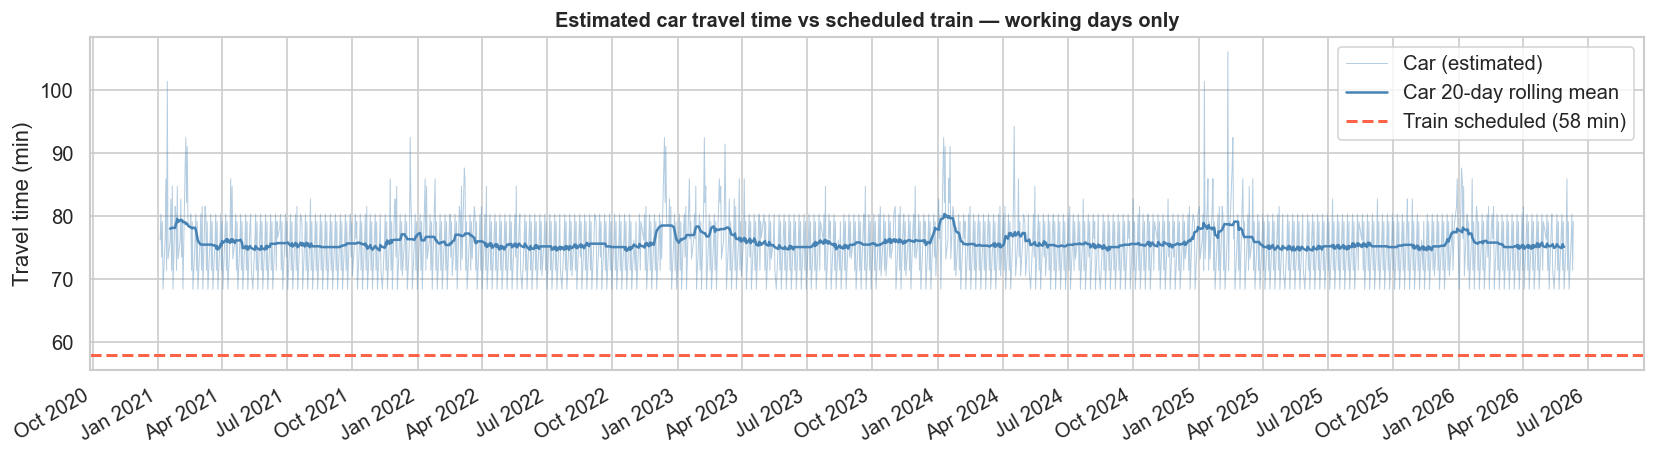


Combined DataFrame is ready for modeling.
Next step: 02_modeling.ipynb — train regression models for car & train travel time,
build decision layer (auto / trein / thuiswerken), and evaluate in business terms.


In [24]:
# Final overview plot: car estimate vs train scheduled time on a timeline
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_combined["date"], df_combined["car_est_min"],
        alpha=0.4, lw=0.6, color="steelblue", label="Car (estimated)")
ax.plot(df_combined["date"],
        df_combined["car_est_min"].rolling(20, center=True).mean(),
        lw=1.5, color="steelblue", label="Car 20-day rolling mean")
ax.axhline(df_combined["train_sched_min"].iloc[0], color="tomato", lw=1.8, ls="--",
           label=f"Train scheduled ({median_train_min:.0f} min)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("Travel time (min)")
ax.set_title("Estimated car travel time vs scheduled train — working days only",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/plot_combined_timeline.png", bbox_inches="tight")
plt.show()

print("\nCombined DataFrame is ready for modeling.")
print("Next step: 02_modeling.ipynb — train regression models for car & train travel time,")
print("build decision layer (auto / trein / thuiswerken), and evaluate in business terms.")